In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os



In [2]:

merged = pd.read_csv("../data/merged.csv")
print(merged.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid_mat', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1_mat', 'G2_mat', 'G3_mat', 'paid_por',
       'G1_por', 'G2_por', 'G3_por'],
      dtype='object')


In [ ]:
# Clustering pour visualiser la heatmap
from sklearn.cluster import AgglomerativeClustering

cls = AgglomerativeClustering(linkage="complete", metric="euclidean")

cluster = cls.fit(merged)

print(cluster)

ValueError: could not convert string to float: 'GP'

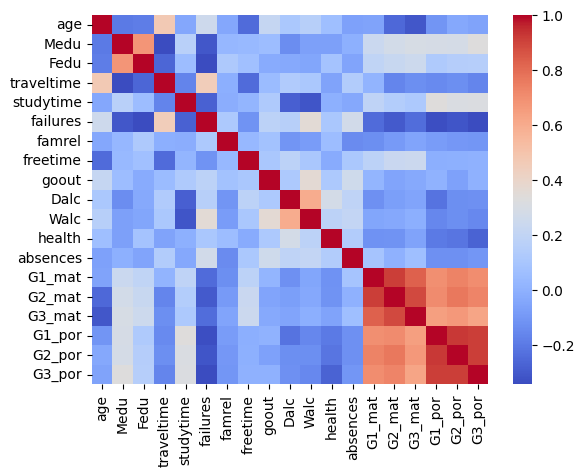

In [3]:
sns.heatmap(merged.corr(numeric_only=True),cmap="coolwarm")
plt.show()

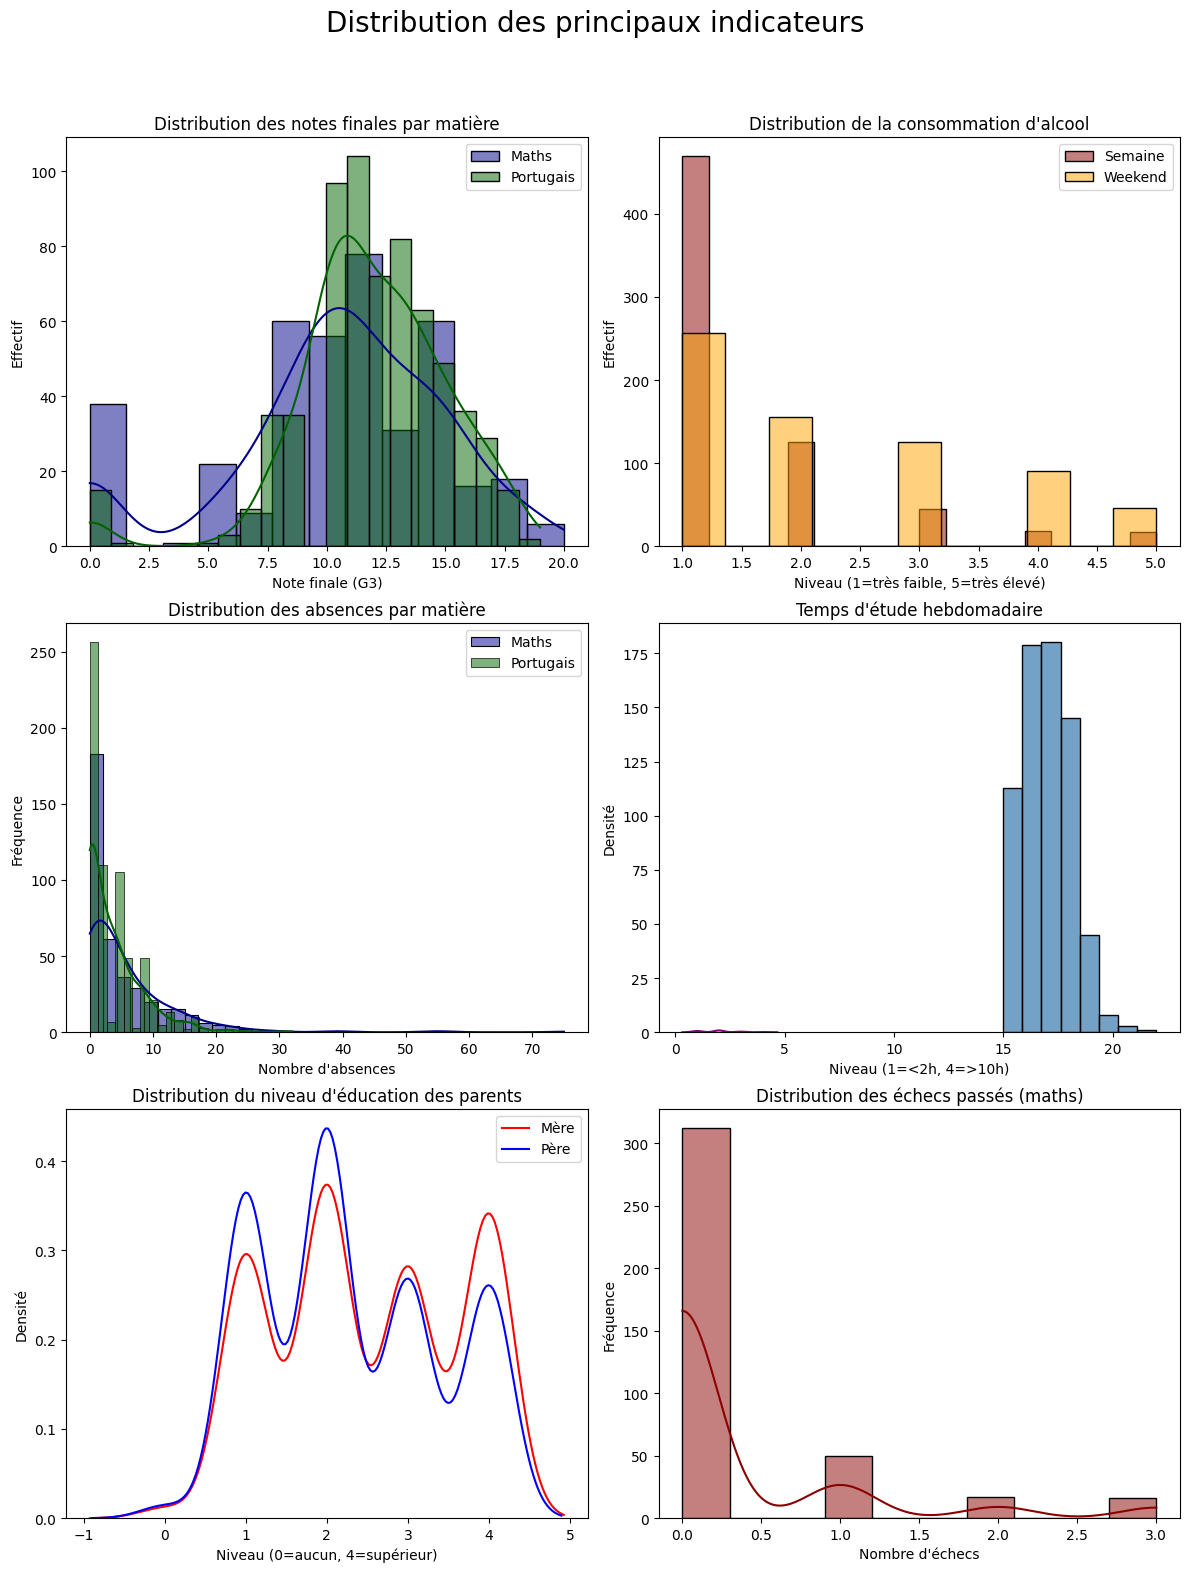

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
fig.suptitle('Distribution des principaux indicateurs', fontsize=20)

# Notes finales math vs portugais
sns.histplot(merged['G3_mat'].dropna(), ax=axes[0, 0], color='darkblue', label='Maths', kde=True, stat='count', alpha=0.5)
sns.histplot(merged['G3_por'].dropna(), ax=axes[0, 0], color='darkgreen', label='Portugais', kde=True, stat='count', alpha=0.5)
axes[0, 0].set_title('Distribution des notes finales par matière')
axes[0, 0].set_xlabel('Note finale (G3)')
axes[0, 0].set_ylabel('Effectif')
axes[0, 0].legend()

# Consommation d'alcool
sns.histplot(merged['Dalc'], ax=axes[0, 1], color='darkred', label='Semaine', stat='count', alpha=0.5)
sns.histplot(merged['Walc'], ax=axes[0, 1], color='orange', label='Weekend', stat='count', alpha=0.5)
axes[0, 1].set_title("Distribution de la consommation d'alcool")
axes[0, 1].set_xlabel('Niveau (1=très faible, 5=très élevé)')
axes[0, 1].set_ylabel('Effectif')
axes[0, 1].legend()


sns.histplot(merged['age'].dropna(), ax=axes[1, 1], color='steelblue', bins=8)
axes[1, 1].set_title("Distribution de l'âge")
axes[1, 1].set_xlabel('Âge')
axes[1, 1].set_ylabel('Fréquence')

# Absences math vs portugais
sns.histplot(merged['absences_mat'].dropna(), kde=True, ax=axes[1, 0], color='darkblue', label='Maths')
sns.histplot(merged['absences_por'].dropna(), kde=True, ax=axes[1, 0], color='darkgreen', label='Portugais')
axes[1, 0].set_title('Distribution des absences par matière')
axes[1, 0].set_xlabel('Nombre d\'absences')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].legend()

# Temps d'étude hebdomadaire
sns.kdeplot(merged['studytime'].dropna(), ax=axes[1, 1], color='purple')
axes[1, 1].set_title("Temps d'étude hebdomadaire")
axes[1, 1].set_xlabel('Niveau (1=<2h, 4=>10h)')
axes[1, 1].set_ylabel('Densité')

# Éducation des parents
sns.kdeplot(merged['Medu'], ax=axes[2, 0], color='red', label='Mère')
sns.kdeplot(merged['Fedu'], ax=axes[2, 0], color='blue', label='Père')
axes[2, 0].set_title('Distribution du niveau d\'éducation des parents')
axes[2, 0].set_xlabel('Niveau (0=aucun, 4=supérieur)')
axes[2, 0].set_ylabel('Densité')
axes[2, 0].legend()

# Échecs passés
sns.histplot(merged['failures_mat'].dropna(), kde=True, ax=axes[2, 1], color='darkred')
axes[2, 1].set_title('Distribution des échecs passés (maths)')
axes[2, 1].set_xlabel('Nombre d\'échecs')
axes[2, 1].set_ylabel('Fréquence')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [13]:
print(merged['failures_mat'])
print(merged['failures_mat'].dtype)
print(merged['failures_mat'].value_counts(dropna=False))

0      1.0
1      NaN
2      2.0
3      0.0
4      0.0
      ... 
669    NaN
670    0.0
671    NaN
672    2.0
673    3.0
Name: failures_mat, Length: 674, dtype: float64
float64
failures_mat
0.0    312
NaN    279
1.0     50
2.0     17
3.0     16
Name: count, dtype: int64
